In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.utils.assemblies import hg19
from cns.process.imputation import get_nan_segs
from cns.process.binning import get_breakpoints, breaks_to_segments, bin_by_segments, add_derived
from cns.analyze.labels import plot_x_ticks, plot_cytobands
from cns.process.segments import breaks_to_segments
from cns.data_utils import load_data

# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data = {
    "PCAWG" : pd.read_csv("../../out/PCAWG_cns_fill.tsv", sep="\t"),
    "TCGA_hg19": pd.read_csv("../../out/TCGA_hg19_cns_fill.tsv", sep="\t"),
    "TRACERx": pd.read_csv("../../out/TRACERx_cns_fill.tsv", sep="\t"),
}
colors = ["cyan", "purple", "green"]

In [6]:
cyto_breaks = get_breakpoints("cytobands", hg19)
cyto_segments = breaks_to_segments(cyto_breaks)
nans = {k: add_derived(get_nan_segs(v), hg19) for k, v in data.items()}
nans["PCAWG"].head()

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
43,SP1003,chr1,249250621,249250621,NaN,NaN,NaN,0,249250621,249250621
175,SP1003,chr2,1,20015,NaN,NaN,NaN,20014,10008,249260629
177,SP1003,chr2,89857500,96799999,NaN,NaN,NaN,6942499,93328749,342579370
179,SP1003,chr2,242999969,243199373,NaN,NaN,NaN,199404,243099671,492350292
192,SP1003,chr3,1,100073,NaN,NaN,NaN,100072,50037,492500031


# NaNs across samples

Text(0.5, 1.0, 'Missing fractions genome')

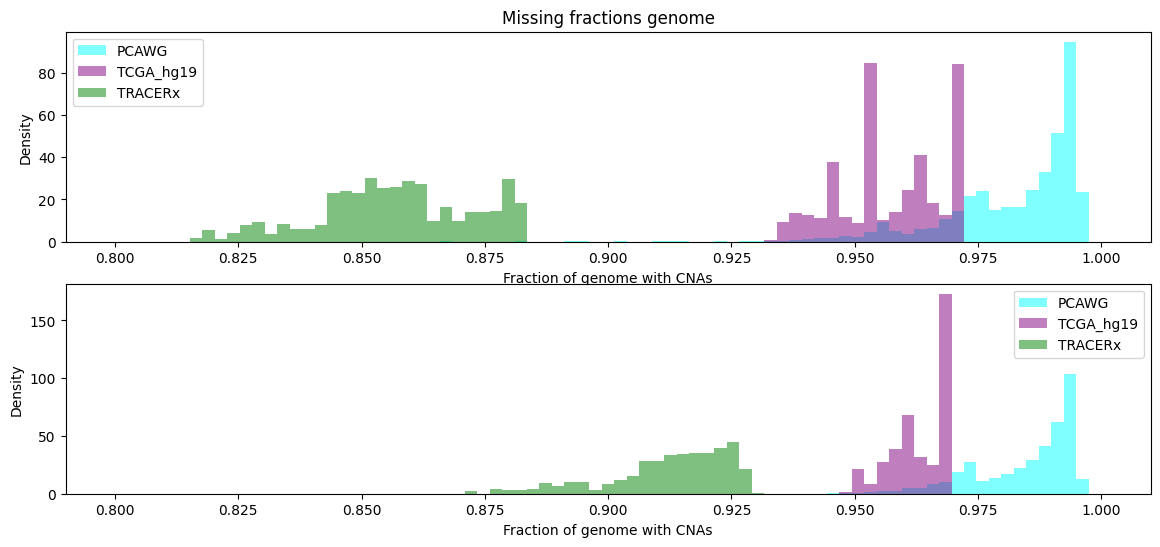

In [7]:
def plot_histogram(ax, nans, genome_length, query=None):
    lengths = {}
    for k, val in nans.items():
        if query:
            val = val.query(query)
        lengths[k] = val.groupby("sample_id")["length"].sum()

    # plot histogram of lengths / genome_length
    for i, (k, v) in enumerate(lengths.items()):
        ax.hist(1 - (v / genome_length), bins=np.linspace(.8, 1, 80), alpha=0.5, color=colors[i], label=k, density=True)

    ax.set_xlabel("Fraction of genome with CNAs")
    ax.set_ylabel("Density")
    ax.legend()

fig, axs = plt.subplots(2, figsize=(14, 6))

plot_histogram(axs[0], nans, hg19.gen_len)
plot_histogram(axs[1], nans,  hg19.aut_len, "chrom != 'chrX' and chrom != 'chrY'")
axs[0].set_title("Missing fractions genome")


# NaNs across cytobands

In [8]:
def _create_new_segments(segments, breakpoints):
    new_segs = []
    current_break = 0
    for i in range(len(segments)):
        while current_break < len(breakpoints) and breakpoints[current_break] < segments[i, 0]:
            current_break += 1
        if current_break >= len(breakpoints):
            new_segs.append(segments[i])
        elif breakpoints[current_break] < segments[i, 1]:
            new_segs.append([segments[i, 0], breakpoints[current_break], segments[i, 2], segments[i, 3]])
            new_segs.append([breakpoints[current_break] + 1, segments[i, 1], segments[i, 2], segments[i, 3]])
        else:
            new_segs.append(segments[i])
        
    new_segs = np.array(new_segs)
    return new_segs


def add_breakpoints(cns_df, breakpoints):
    indexed = cns_df.set_index(["sample_id", "chrom"])
    new_frames = []
    breakpoints = {k: np.sort(v) for k, v in breakpoints}
    for (sample_id, chrom), df in indexed.groupby(level=[0, 1]):
        new_regs = _create_new_segments(df[["start", "end", "major_cn", "minor_cn"]].values, breakpoints[chrom])
        new_df = pd.DataFrame(new_regs, columns=["start", "end", "major_cn", "minor_cn"])
        new_df["sample_id"] = sample_id
        new_df["chrom"] = chrom
        new_frames.append(new_df)
    res = pd.concat(new_frames)
    res["start"] = res["start"].astype(int)
    res["end"] = res["end"].astype(int)
    return res[["sample_id", "chrom", "start", "end", "major_cn", "minor_cn"]]

In [9]:
# TODO: Scale the band regions by the region size
res = { k: add_derived(add_breakpoints(v, cyto_breaks), hg19) for k, v in nans.items() }
res["PCAWG"].head()

In [ ]:
def get_linear_breaks(cyto_breaks, chr_cum_starts):
    cyto_cum_breaks = []
    breakpoints = {k: v for k, v in cyto_breaks}
    for chrom in hg19.chr_names:
        new_breaks = [chr_cum_starts[chrom] + cyto_break for cyto_break in breakpoints[chrom]]
        cyto_cum_breaks += new_breaks
    return cyto_cum_breaks

In [ ]:
cyto_cum_breaks = get_linear_breaks(cyto_breaks, hg19.chr_starts)

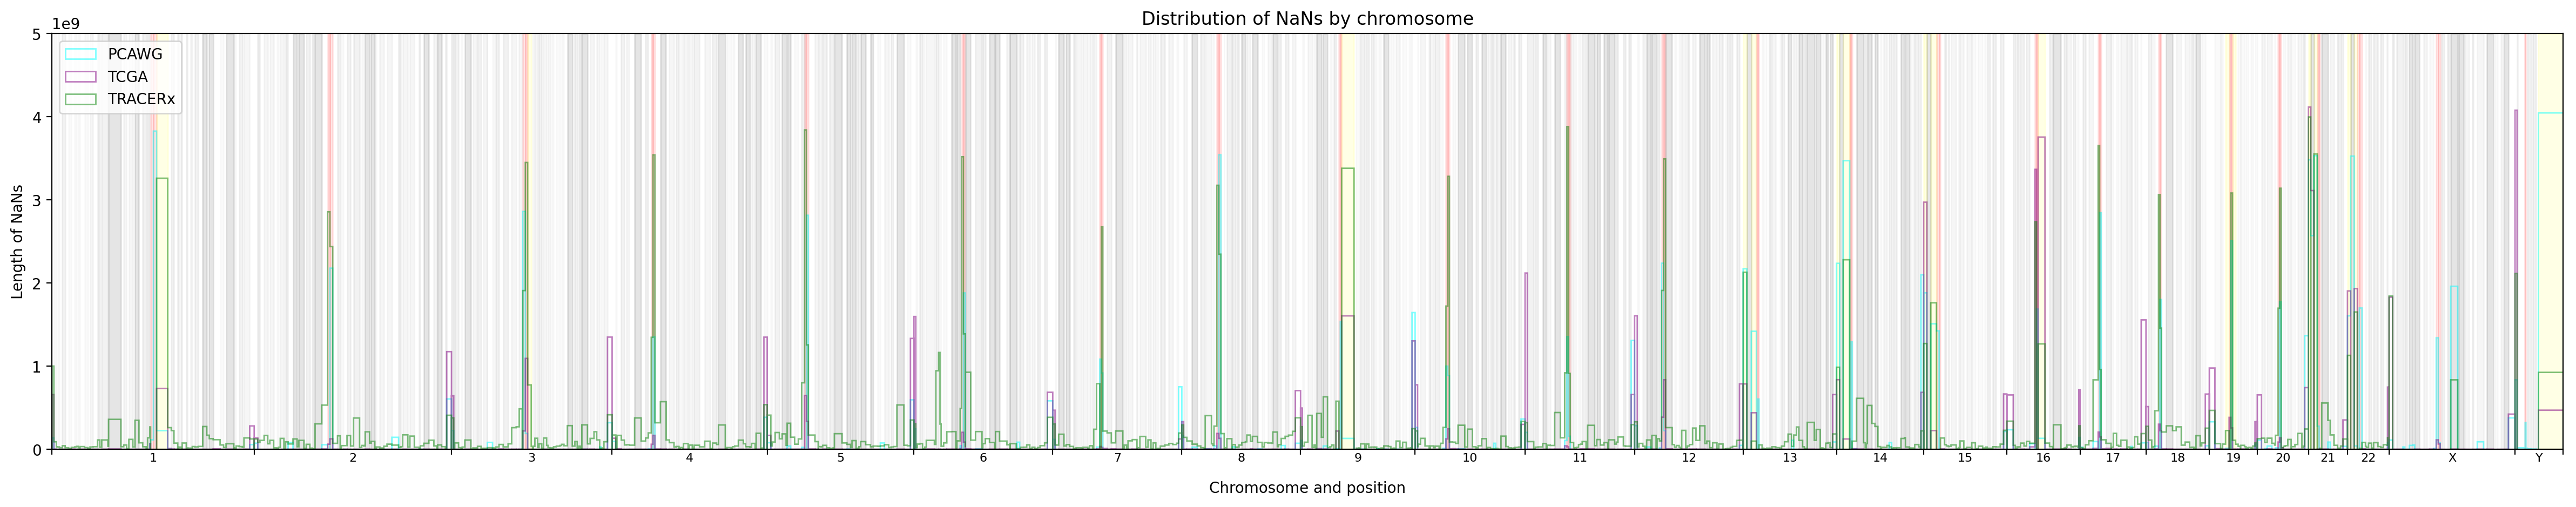

In [ ]:
fig, ax = plt.subplots(1, figsize=(30, 5), dpi = 200)

max_y = 5e9
plot_cytobands(ax, hg19, 0, max_y, alpha=.1)
plot_x_ticks(ax, hg19)

def plot_nans(ax, nans_df, bins, dataset, color="blue"):
    ax.hist(nans_df["cum_mid"], weights=nans_df["length"], bins=bins, histtype = "step", color=color, lw=1, alpha=.5, label=dataset)

plot_nans(ax, res["PCAWG"], cyto_cum_breaks, "PCAWG", color="cyan")
plot_nans(ax, res["TCGA_hg19"], cyto_cum_breaks, "TCGA", color="purple")
plot_nans(ax, res["TRACERx"], cyto_cum_breaks, "TRACERx", color="green")

ax.set_title(f"Distribution of NaNs by chromosome")
ax.set_xlabel("Chromosome and position")
ax.set_ylabel("Length of NaNs")

ax.legend()

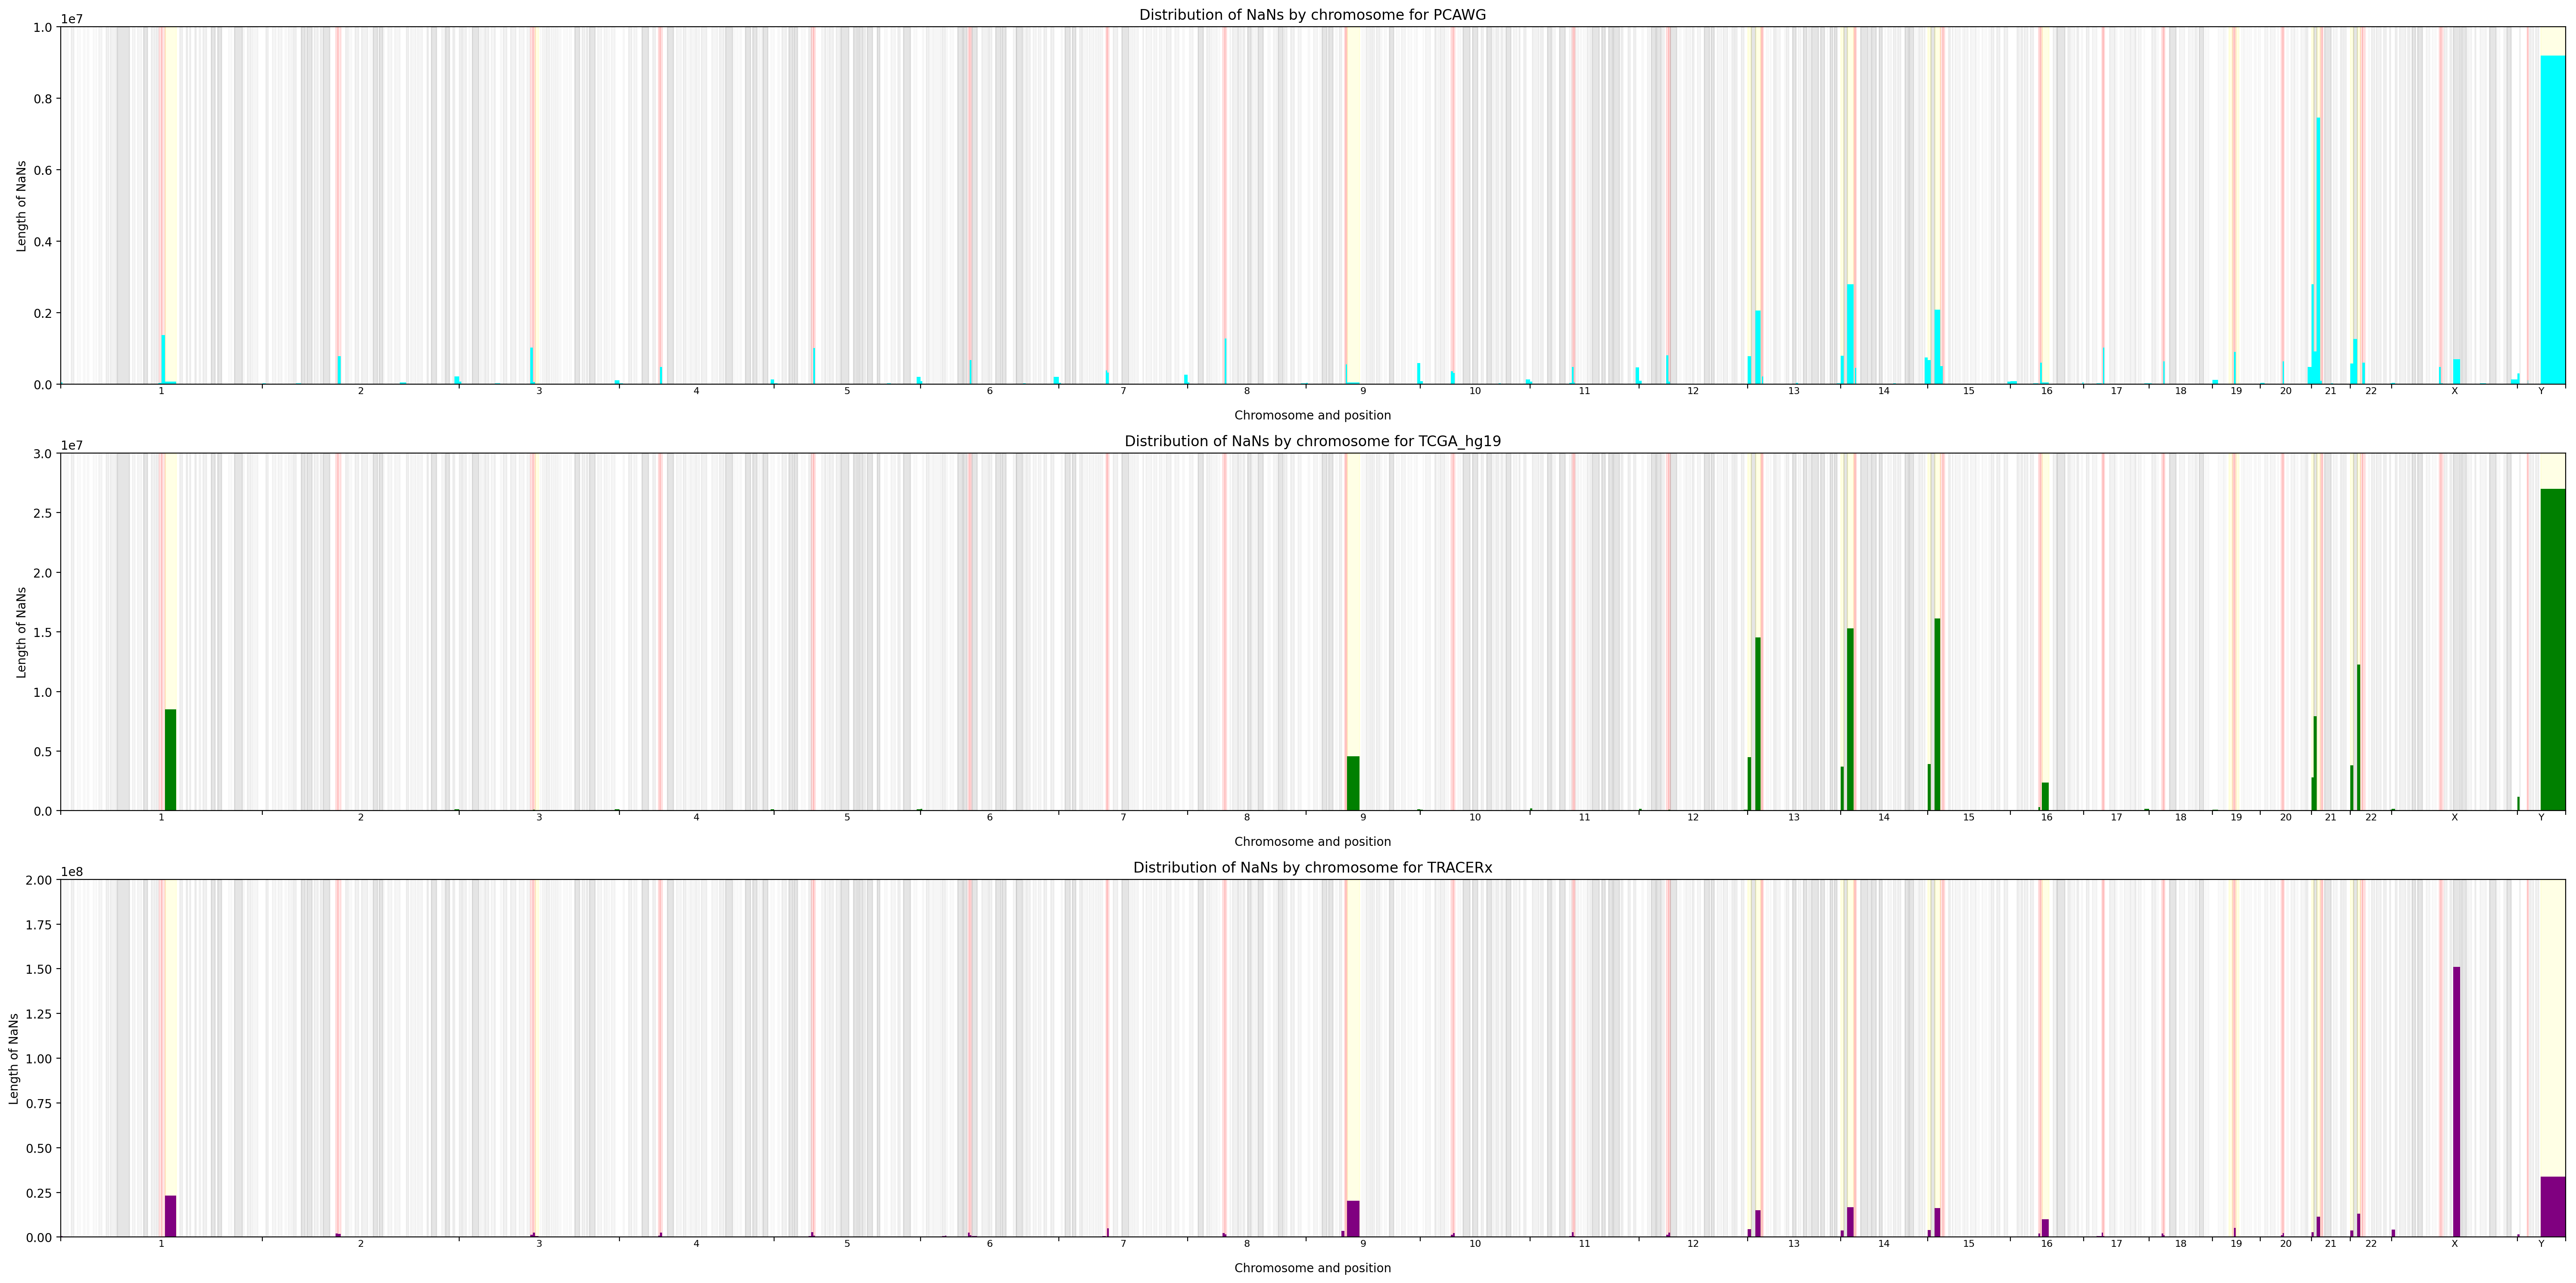

In [ ]:
fig, axs = plt.subplots(3, figsize=(30, 15), dpi=200)  # Create 3 subplots


def plot_nans(ax, nans_df, bins, dataset, color="blue", max_y=1e8):
    plot_cytobands(ax, hg19, 0, max_y, alpha=.1)
    plot_x_ticks(ax, hg19)
    sample_count = nans_df["sample_id"].nunique()
    ax.hist(nans_df["cum_mid"], weights=nans_df["length"]/sample_count, bins=bins, color=color, label=dataset)

# Plot each histogram on a separate subplot
plot_nans(axs[0], res["PCAWG"], cyto_cum_breaks, "PCAWG", color="cyan", max_y=1e7)
plot_nans(axs[1], res["TCGA_hg19"], cyto_cum_breaks, "TCGA", color="green", max_y=3e7)
plot_nans(axs[2], res["TRACERx"], cyto_cum_breaks, "TRACERx", color="purple", max_y=2e8)

names = ["PCAWG", "TCGA_hg19", "TRACERx"]
# Set titles and labels for each subplot
for i, ax in enumerate(axs):
    ax.set_title(f"Distribution of NaNs by chromosome for {names[i]}")
    ax.set_xlabel("Chromosome and position")
    ax.set_ylabel("Length of NaNs")

plt.tight_layout()  # Ensure subplots do not overlap
plt.show()